In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('tips.csv')
df.head()

,total_bill,tip,gender,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3.560330e+15,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4.478070e+15,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6.011810e+15,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4.676140e+15,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4.832730e+15,Sun2251


#### Line Plot

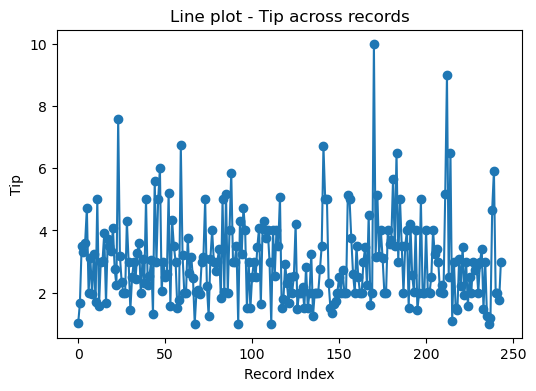

In [4]:
plt.figure(figsize=(6,4))
plt.plot(df.index,df["tip"],marker="o")
plt.title("Line plot - Tip across records")
plt.xlabel("Record Index")
plt.ylabel("Tip")
plt.show()

#### Bar plot

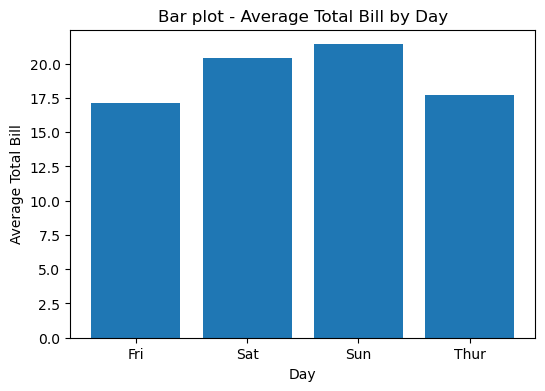

In [8]:
avg_bill_day = df.groupby("day")["total_bill"].mean()
plt.figure(figsize=(6,4))
plt.bar(avg_bill_day.index,avg_bill_day.values)
plt.title("Bar plot - Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()

In [6]:
avg_bill_day = df.groupby("day")["total_bill"].mean()
avg_bill_day.head()

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

#### Histogram

##### Distribution of total_bill

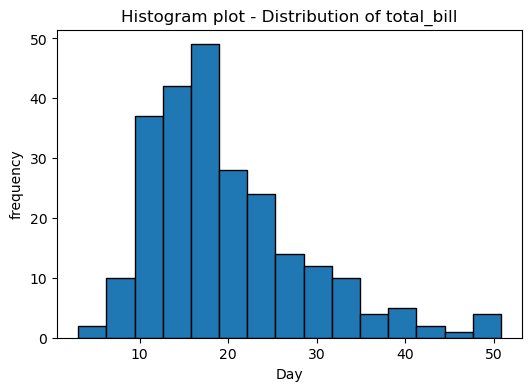

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["total_bill"],bins=15,edgecolor = "black")
plt.title("Histogram plot - Distribution of total_bill")
plt.xlabel("Day")
plt.ylabel("frequency")
plt.show()

#### Box plot

##### Tip spread by day

C:\Users\pgcp-bda\AppData\Local\Temp\ipykernel_6504\1626517603.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(tip_by_day,labels=df["day"].unique())


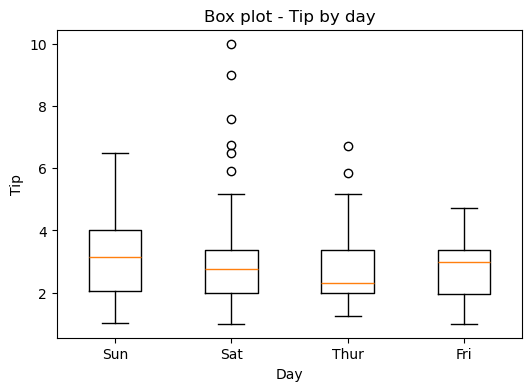

In [22]:
tip_by_day = [ df[df["day"] == d]["tip"] for d in df["day"].unique()]
# df["day"].unique() = > Sun,Sat,Thrus,Fri
# so the for loop becomes for d in ['Sun','Sat','Thrus','Fri']
# end result
# [
#   series for Sun,
#   series for Sat,
#   series for Thrus,
#   series for Fri
# ]
plt.figure(figsize=(6,4))
plt.boxplot(tip_by_day,labels=df["day"].unique())
plt.title("Box plot - Tip by day")
plt.xlabel("Day")
plt.ylabel("Tip")
plt.show()

#### Scatter Plot

##### total_bill vs tip

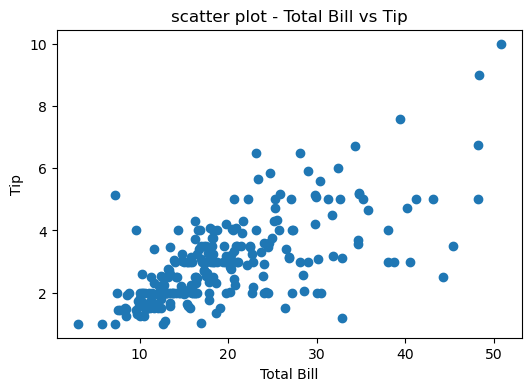

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df["total_bill"],df["tip"])
plt.title("scatter plot - Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

#### Pie Chart

##### Percentage of bills by day

In [19]:
day_counts=df["day"].value_counts()
day_counts

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

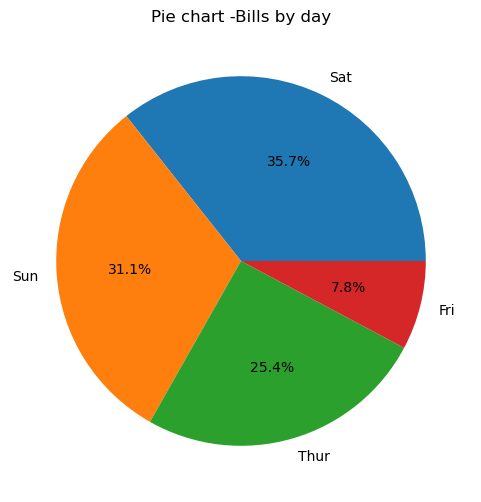

In [20]:
day_counts=df["day"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(day_counts.values,labels=day_counts.index,autopct="%1.1f%%")

plt.title("Pie chart -Bills by day")
plt.show()

#### Heatmap

## Seaborn

#### Line Plot

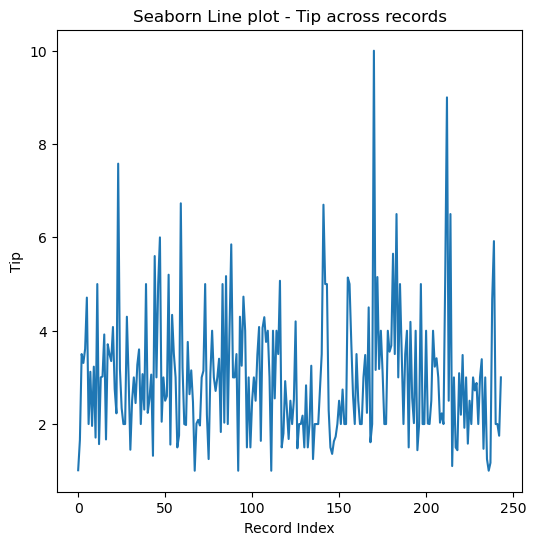

In [24]:
plt.figure(figsize=(6,6))
sns.lineplot(x=df.index,y=df["tip"])
plt.title("Seaborn Line plot - Tip across records")
plt.xlabel("Record Index")
plt.ylabel("Tip")
plt.show()

#### Bar Plot

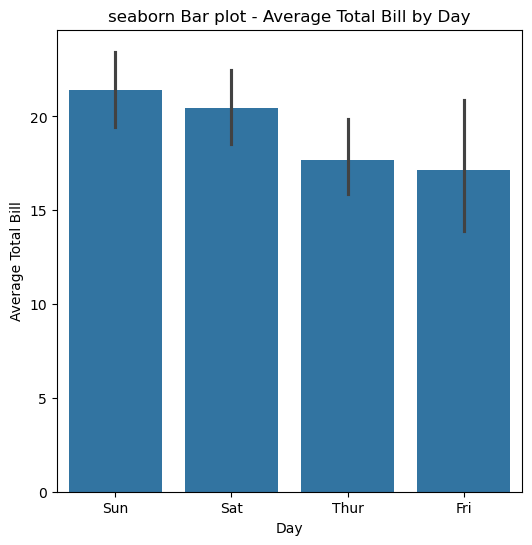

In [38]:
plt.figure(figsize=(6,6))
sns.barplot(x="day",y="total_bill",data=df)
plt.title("seaborn Bar plot - Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()
# The thin black vertical line = error bar
# Error bar says actual bills vary above and below 

#### Histogram

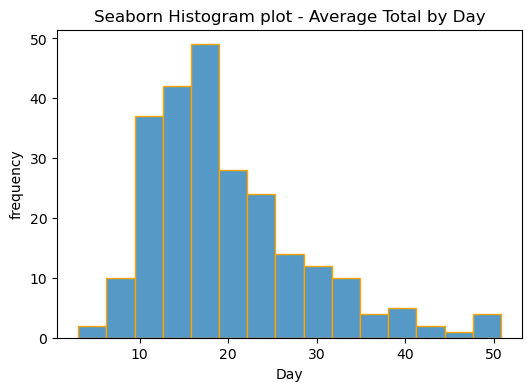

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df["total_bill"],bins=15,edgecolor = "orange")
plt.title("Seaborn Histogram plot - Average Total by Day")
plt.xlabel("Day")
plt.ylabel("frequency")
plt.show()

#### Boxplot

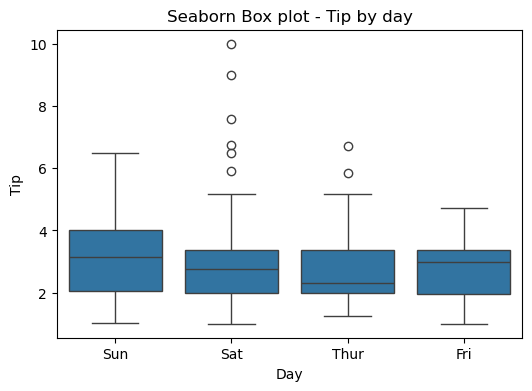

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x="day",y="tip",data=df)
plt.title("Seaborn Box plot - Tip by day")
plt.xlabel("Day")
plt.ylabel("Tip")
plt.show()

#### Scatter Plot

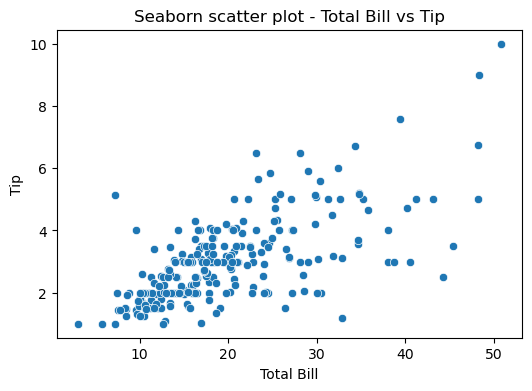

In [37]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="total_bill",y="tip",data=df)
plt.title("Seaborn scatter plot - Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

#### Pie Chart

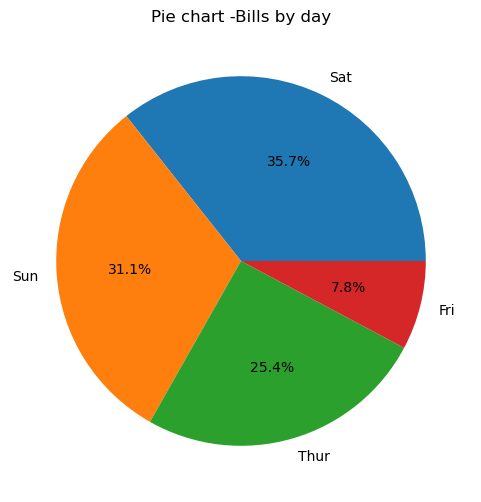

In [39]:
plt.figure(figsize=(6,6))
plt.pie(day_counts.values,labels=day_counts.index,autopct="%1.1f%%")

plt.title("Pie chart -Bills by day")
plt.show()

#### Heatmap

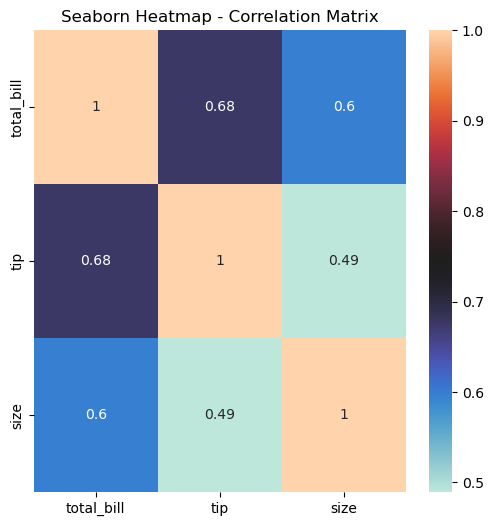

In [58]:
corr= df[["total_bill","tip","size"]].corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr,annot=True, cmap="icefire")
plt.title("Seaborn Heatmap - Correlation Matrix")
plt.show()

### Subplot

1. Functional oriented syntax
2. object oriented syntax

1. Functional oriented syntax

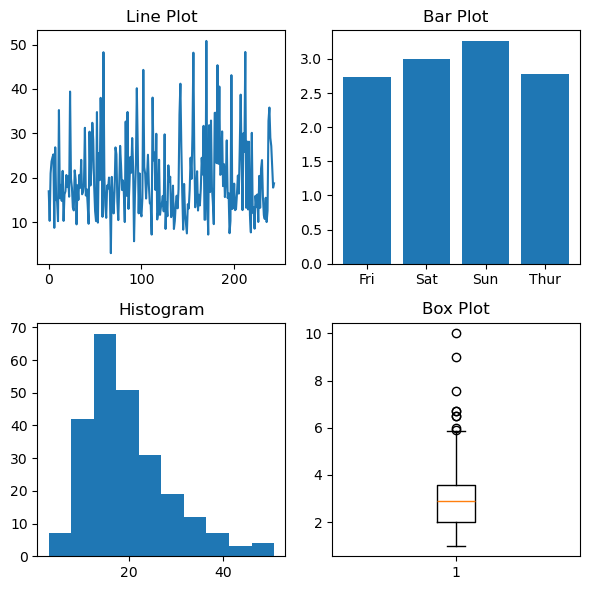

In [60]:
avg_tip_by_day = df.groupby("day")["tip"].mean()
corr= df[["total_bill","tip","size"]].corr()

plt.figure(figsize=(6,6))

# Line
plt.subplot(2,2,1)
plt.plot(df.index,df["total_bill"])
plt.title("Line Plot")

# bar
plt.subplot(2,2,2)
plt.bar(avg_tip_by_day.index,avg_tip_by_day.values)
plt.title("Bar Plot")

# histogram
plt.subplot(2,2,3)
plt.hist(df["total_bill"],bins=10)
plt.title("Histogram")

# boxplot
plt.subplot(2,2,4)
plt.boxplot(df["tip"])
plt.title("Box Plot")

plt.tight_layout()
plt.show()

#### Object-Oriented Style

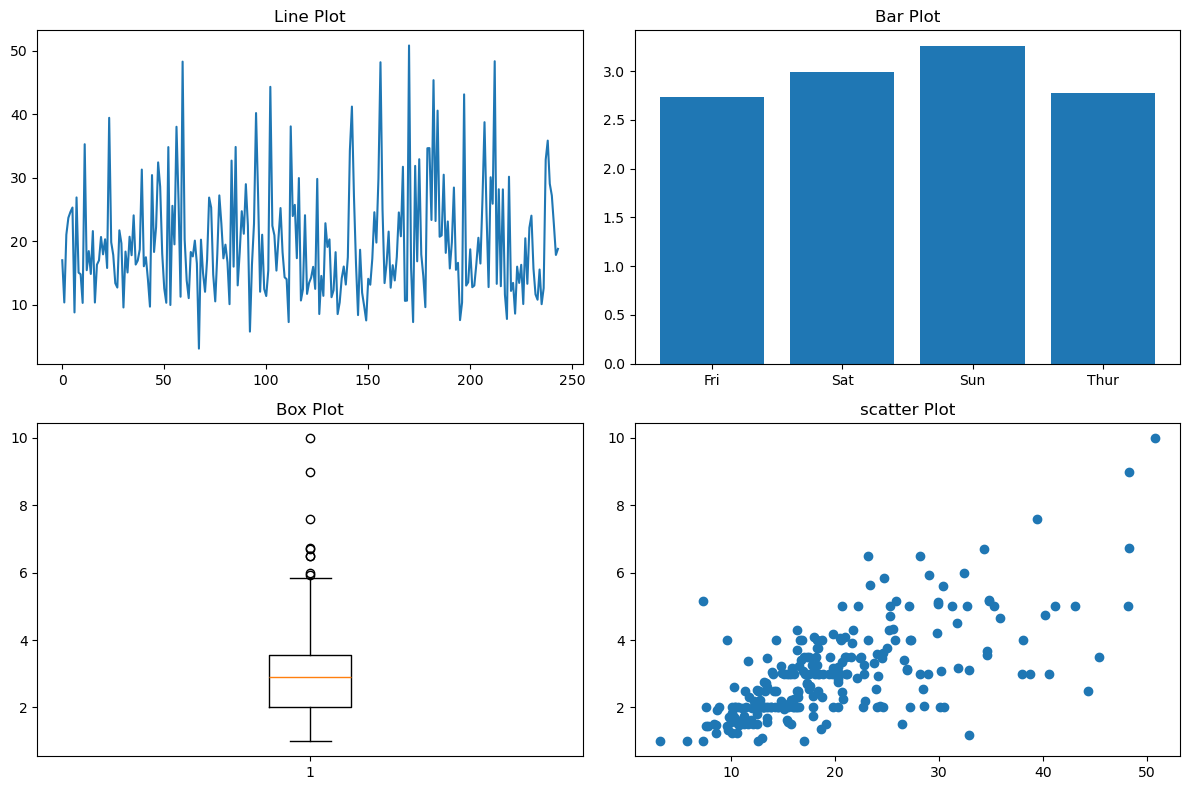

In [64]:
fig,axes=plt.subplots(2,2,figsize=(12,8))

#Line
axes[0,0].plot(df.index,df["total_bill"])
axes[0,0].set_title("Line Plot")

# Bar
axes[0,1].bar(avg_tip_by_day.index,avg_tip_by_day.values)
axes[0,1].set_title("Bar Plot")

# Box
axes[1,0].boxplot(df["tip"])
axes[1,0].set_title("Box Plot")

# scatter
axes[1,1].scatter(df["total_bill"],df["tip"])
axes[1,1].set_title("scatter Plot")

plt.tight_layout()
plt.show()